# Advanced Optimization Problems with Generative Models

This notebook extends the basic examples to more challenging and interesting optimization problems.

## Table of Contents

1. [Setup](#setup)
2. [Multi-modal Optimization (Rastrigin)](#multimodal)
3. [Multi-objective / Pareto Front](#pareto)
4. [Inverse Design (Alloy Properties)](#inverse-design)
5. [PDE-Constrained Optimization (Heat Equation)](#pde)
6. [Trajectory Optimization / Optimal Control](#trajectory)
7. [Robust Optimization Under Uncertainty](#robust)
8. [Facility Location Problem](#facility)
9. [Equation of State Fitting](#eos)

---
<a id='setup'></a>
## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
import warnings
import os

# Force CPU for JAX
os.environ['JAX_PLATFORMS'] = 'cpu'

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.integrate import solve_ivp, odeint
from scipy.stats.qmc import Sobol, scale
from scipy.optimize import minimize
from scipy.interpolate import interp1d
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from gmr import GMM
from tqdm.auto import tqdm

# Force CPU for PyTorch
device = torch.device('cpu')
print(f"Using device: {device}")

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


In [2]:
# Utility functions
def generate_samples(bounds, n_samples=None, method='sobol', seed=42):
    """Generate samples in a bounded region."""
    bounds = np.atleast_2d(bounds)
    n_dims = len(bounds)
    
    if n_samples is None:
        n_samples = 2 ** int(np.ceil(np.log2(20 * n_dims)))
        n_samples = min(n_samples, 4096)
    
    if method == 'sobol':
        sampler = Sobol(d=n_dims, scramble=True, seed=seed)
        n_samples = 2 ** int(np.ceil(np.log2(n_samples)))
        raw = sampler.random(n=n_samples)
    else:
        rng = np.random.default_rng(seed)
        raw = rng.uniform(0, 1, (n_samples, n_dims))
    
    return scale(raw, bounds[:, 0], bounds[:, 1])


def best_gmm(X, max_components=None, patience=10, verbose=False):
    """Find best GMM using BIC with early stopping."""
    X = np.atleast_2d(X)
    n_samples, n_features = X.shape
    
    if max_components is None:
        max_components = min(50, max(2, n_samples // (5 * n_features)))
    
    best_score = np.inf
    best_k = 1
    best_model = None
    no_improvement = 0
    
    for k in range(1, max_components + 1):
        try:
            model = GaussianMixture(n_components=k, covariance_type='full',
                                   reg_covar=1e-6, n_init=3, random_state=42).fit(X)
            score = model.bic(X)
            
            if score < best_score:
                best_score = score
                best_k = k
                best_model = model
                no_improvement = 0
            else:
                no_improvement += 1
            
            if verbose:
                print(f"k={k}: BIC={score:.1f}")
            
            if no_improvement >= patience:
                break
        except:
            continue
    
    gmm = GMM(n_components=best_model.n_components,
              priors=best_model.weights_,
              means=best_model.means_,
              covariances=best_model.covariances_)
    return gmm


def cluster_stats(X, eps=0.5, min_samples=5):
    """Compute statistics for clusters."""
    X = np.atleast_2d(X)
    if X.shape[0] == 1:
        X = X.T
    
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
    labels = clustering.labels_
    
    stats = {}
    for L in sorted(set(labels)):
        if L == -1:
            continue
        mask = labels == L
        cluster_data = X[mask]
        mean = np.mean(cluster_data, axis=0)
        std = np.std(cluster_data, axis=0)
        stats[L] = {'mean': mean, 'std': std, 'n': np.sum(mask)}
        print(f'{L:3d}: mean={mean}, std={std} (n={np.sum(mask)})')
    return stats

---
<a id='multimodal'></a>
## 2. Multi-modal Optimization (Rastrigin Function)

The Rastrigin function has many local minima but a known global minimum at the origin:

$$f(\mathbf{x}) = 10n + \sum_{i=1}^{n} \left[ x_i^2 - 10\cos(2\pi x_i) \right]$$

We'll show how generative models can find multiple local minima by conditioning on gradient = 0.

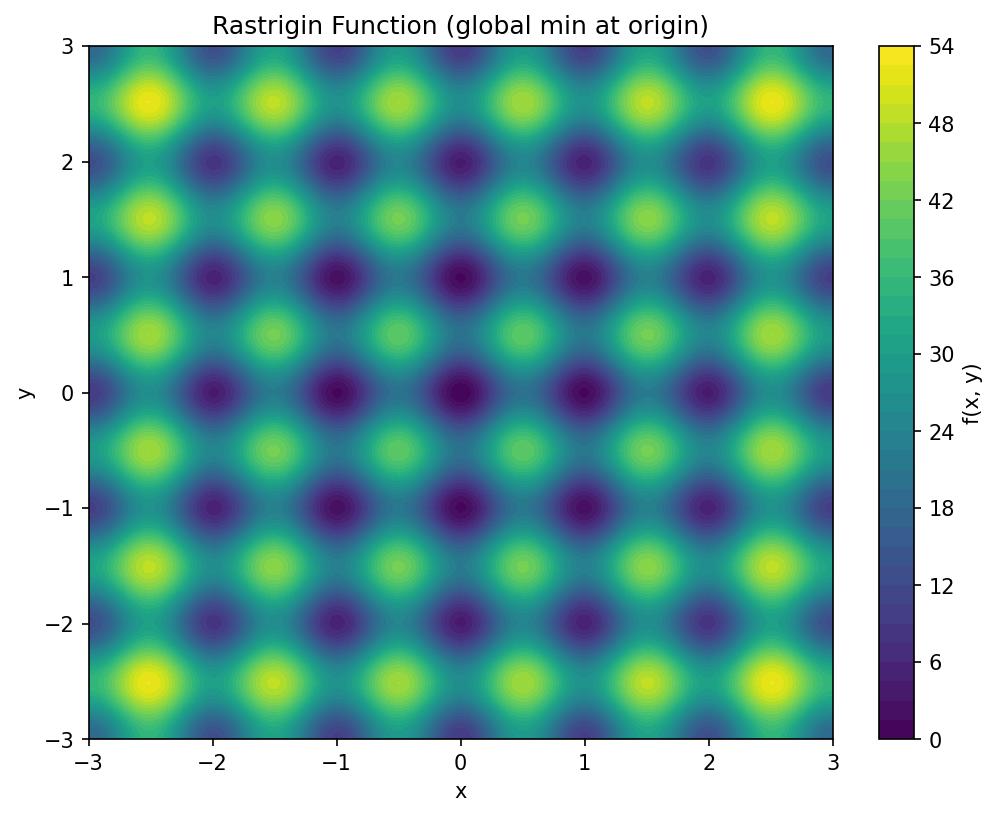

In [3]:
# Rastrigin function (2D)
def rastrigin(X):
    x, y = X[:, 0], X[:, 1]
    return 10*2 + (x**2 - 10*np.cos(2*np.pi*x)) + (y**2 - 10*np.cos(2*np.pi*y))

def rastrigin_grad(X):
    x, y = X[:, 0], X[:, 1]
    df_dx = 2*x + 20*np.pi*np.sin(2*np.pi*x)
    df_dy = 2*y + 20*np.pi*np.sin(2*np.pi*y)
    return np.column_stack([df_dx, df_dy])

# Visualize
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
Z = rastrigin(np.column_stack([X.ravel(), Y.ravel()])).reshape(X.shape)

fig, ax = plt.subplots(figsize=(8, 6))
c = ax.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(c, label='f(x, y)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Rastrigin Function (global min at origin)')
plt.show()

In [4]:
# Generate training data: sample (x, y) and compute gradients
bounds = [[-3, 3], [-3, 3]]
samples = generate_samples(bounds, n_samples=2048, seed=42)

# Compute function values and gradients
f_values = rastrigin(samples)
gradients = rastrigin_grad(samples)

# Data: [x, y, f, df/dx, df/dy]
data = np.column_stack([samples, f_values, gradients])
print(f"Data shape: {data.shape}")

Data shape: (2048, 5)


In [5]:
# Build GMM to find stationary points (gradient = 0)
gmm_rast = best_gmm(data)

# Condition on gradients = 0
c = gmm_rast.condition([3, 4], [[0.0, 0.0]])
stationary_samples = c.sample(2000)

# Evaluate function at sampled points
f_at_samples = rastrigin(stationary_samples[:, :2])

print(f"Found {len(stationary_samples)} candidate stationary points")
print(f"Function values range: [{f_at_samples.min():.2f}, {f_at_samples.max():.2f}]")

Found 2000 candidate stationary points
Function values range: [0.01, 75.68]


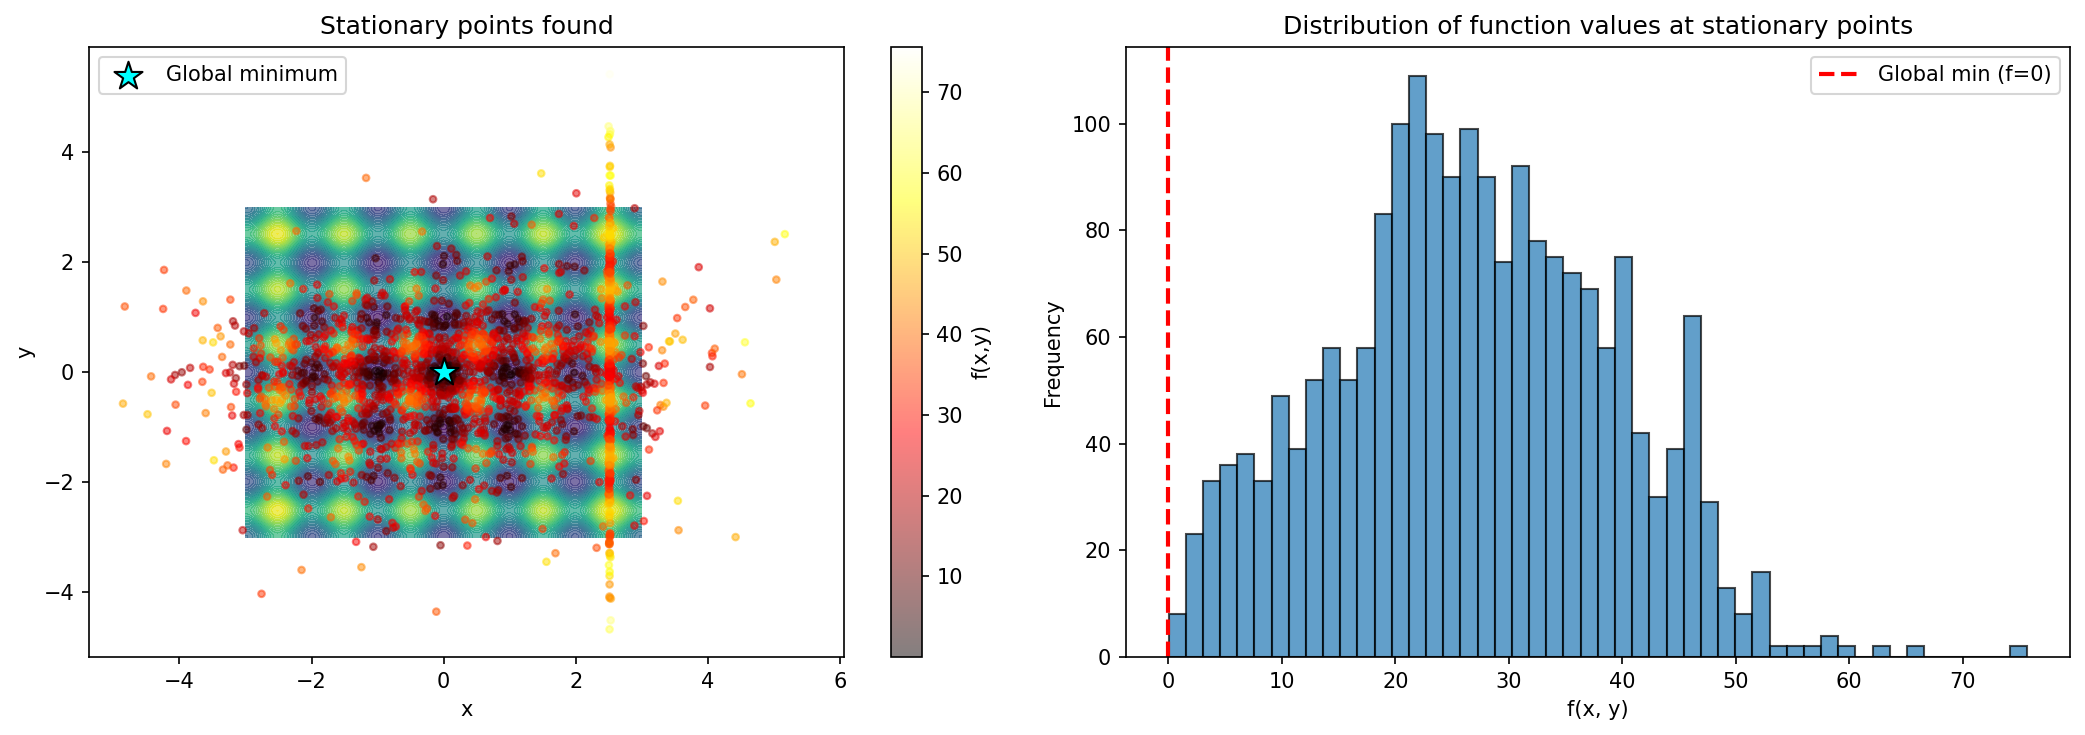


Points near global minimum (f < 1.0): 4
Mean position: [0.00619384 0.00797153]


In [6]:
# Visualize found stationary points
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter on contour
axes[0].contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
scatter = axes[0].scatter(stationary_samples[:, 0], stationary_samples[:, 1], 
                          c=f_at_samples, cmap='hot', s=10, alpha=0.5)
axes[0].scatter([0], [0], c='cyan', s=200, marker='*', edgecolors='black',
                label='Global minimum', zorder=5)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Stationary points found')
axes[0].legend()
plt.colorbar(scatter, ax=axes[0], label='f(x,y)')

# Right: histogram of function values
axes[1].hist(f_at_samples, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='r', ls='--', lw=2, label='Global min (f=0)')
axes[1].set_xlabel('f(x, y)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of function values at stationary points')
axes[1].legend()

plt.tight_layout()
plt.show()

# Find points near global minimum
near_global = stationary_samples[f_at_samples < 1.0]
print(f"\nPoints near global minimum (f < 1.0): {len(near_global)}")
if len(near_global) > 0:
    print(f"Mean position: {near_global[:, :2].mean(axis=0)}")

In [7]:
# Find the global minimum specifically by conditioning on gradient=0 AND low f value
# Include function value in conditioning
c_global = gmm_rast.condition([2, 3, 4], [[0.0, 0.0, 0.0]])  # f=0, grad=0
global_samples = c_global.sample(500)

print("Samples targeting global minimum (f=0, grad=0):")
print(f"  Mean position: {global_samples[:, :2].mean(axis=0)}")
print(f"  Std position: {global_samples[:, :2].std(axis=0)}")
print(f"  True global min: [0, 0]")

Samples targeting global minimum (f=0, grad=0):
  Mean position: [0.4225088  0.09401381]
  Std position: [1.66196887 0.98679789]
  True global min: [0, 0]


---
<a id='pareto'></a>
## 3. Multi-objective Optimization / Pareto Front

**ZDT1** is a standard benchmark problem for multi-objective optimization, named after its creators Zitzler, Deb, and Thiele (2000).

### Mathematical Definition

For a decision vector **x** = (x₁, x₂, ..., xₙ) where xᵢ ∈ [0, 1]:

**Objective 1:** $f_1(x) = x_1$

**Objective 2:** $f_2(x) = g(x) \cdot h(f_1, g)$

where:
$$g(x) = 1 + \frac{9}{n-1} \sum_{i=2}^{n} x_i$$
$$h(f_1, g) = 1 - \sqrt{\frac{f_1}{g}}$$

### Key Properties

| Property | Value |
|----------|-------|
| Decision variables | n (we use 3 for simplicity) |
| Objectives | 2 (minimize both f₁ and f₂) |
| Domain | [0, 1]ⁿ |
| Pareto front | Convex |
| Optimal condition | x₂ = x₃ = ... = xₙ = 0 |

### Pareto Front

The true Pareto front occurs when g(x) = 1 (all variables except x₁ are zero):
$$f_2 = 1 - \sqrt{f_1}$$

This gives a convex front from (0, 1) to (1, 0).

### Why ZDT1 is Used

ZDT1 tests an algorithm's ability to:
- Find the full Pareto front (not just endpoints)
- Maintain diversity along the front
- Converge to the true optimal front
- Handle many decision variables (scalable difficulty)

**References:**
- Zitzler, E., Deb, K., & Thiele, L. (2000). Comparison of multiobjective evolutionary algorithms: Empirical results. *Evolutionary Computation*, 8(2), 173-195.
- Huband, S., Hingston, P., Barone, L., & While, L. (2006). A review of multiobjective test problems and a scalable test problem toolkit. *IEEE Transactions on Evolutionary Computation*, 10(5), 477-506.

In [8]:
# ZDT1 problem (3 decision variables for simplicity)
def zdt1(X):
    """ZDT1 multi-objective function."""
    n = X.shape[1]
    f1 = X[:, 0]
    g = 1 + 9 * X[:, 1:].sum(axis=1) / (n - 1)
    h = 1 - np.sqrt(f1 / g)
    f2 = g * h
    return np.column_stack([f1, f2])

# Generate data
n_vars = 3
bounds = [[0, 1]] * n_vars
X = generate_samples(bounds, n_samples=2048, seed=42)

# Compute objectives
F = zdt1(X)

# Data: [x1, x2, x3, f1, f2]
data = np.column_stack([X, F])
print(f"Data shape: {data.shape}")

Data shape: (2048, 5)


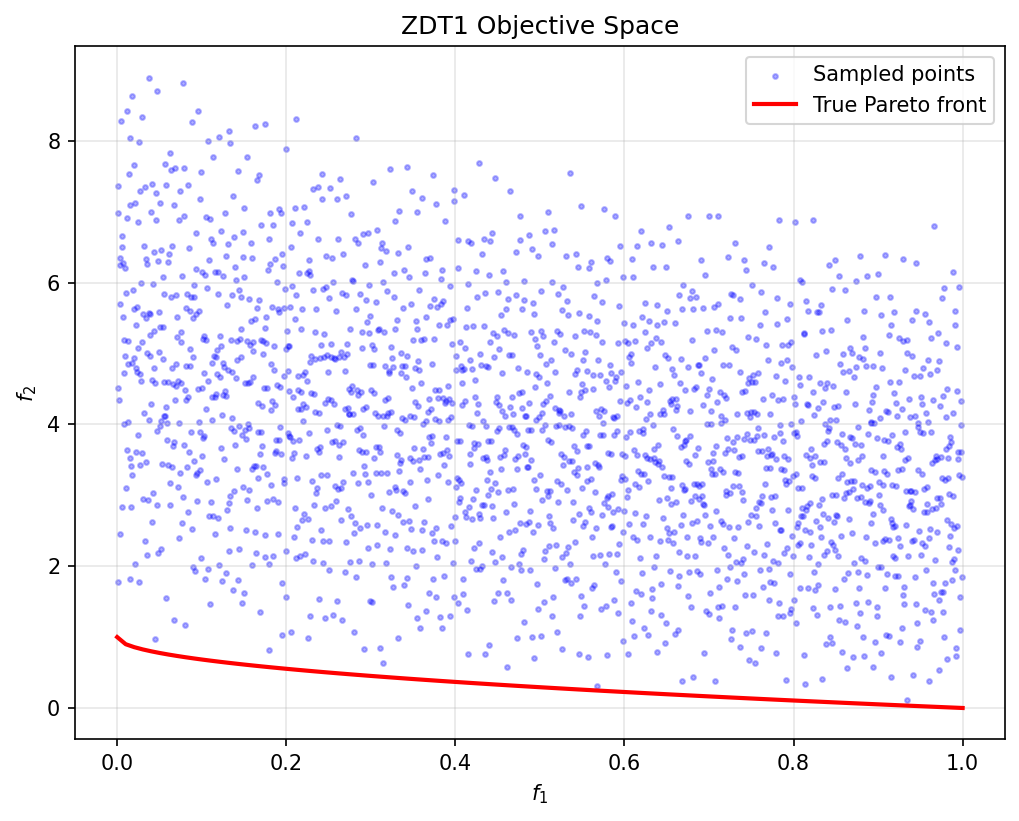

In [9]:
# Visualize objective space
plt.figure(figsize=(8, 6))
plt.scatter(F[:, 0], F[:, 1], c='blue', s=5, alpha=0.3, label='Sampled points')

# True Pareto front
f1_true = np.linspace(0, 1, 100)
f2_true = 1 - np.sqrt(f1_true)
plt.plot(f1_true, f2_true, 'r-', lw=2, label='True Pareto front')

plt.xlabel('$f_1$')
plt.ylabel('$f_2$')
plt.title('ZDT1 Objective Space')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Build GMM: generate x given desired (f1, f2) on Pareto front
gmm_pareto = best_gmm(data)

# Sample points along the Pareto front
f1_targets = np.linspace(0.1, 0.9, 9)
f2_targets = 1 - np.sqrt(f1_targets)

pareto_solutions = []
for f1, f2 in zip(f1_targets, f2_targets):
    # Condition on desired objectives
    pred = gmm_pareto.predict([3, 4], np.array([[f1, f2]]))
    pareto_solutions.append(pred[0])

pareto_solutions = np.array(pareto_solutions)
print(f"Generated {len(pareto_solutions)} Pareto-optimal solutions")

Generated 9 Pareto-optimal solutions


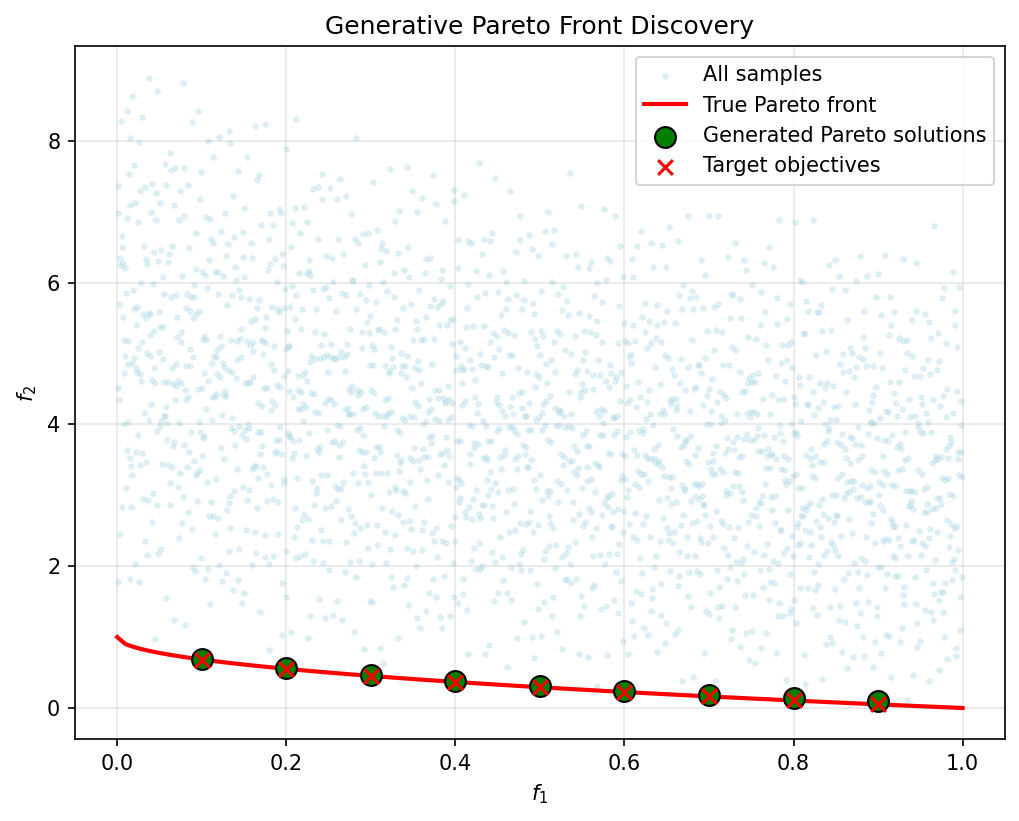


Target vs Achieved objectives:
  Target: (0.10, 0.68) -> Achieved: (0.100, 0.689)
  Target: (0.20, 0.55) -> Achieved: (0.200, 0.563)
  Target: (0.30, 0.45) -> Achieved: (0.300, 0.466)
  Target: (0.40, 0.37) -> Achieved: (0.400, 0.384)
  Target: (0.50, 0.29) -> Achieved: (0.500, 0.315)
  Target: (0.60, 0.23) -> Achieved: (0.600, 0.237)
  Target: (0.70, 0.16) -> Achieved: (0.700, 0.184)
  Target: (0.80, 0.11) -> Achieved: (0.800, 0.141)
  Target: (0.90, 0.05) -> Achieved: (0.900, 0.103)


In [11]:
# Verify: compute objectives for generated solutions
F_generated = zdt1(pareto_solutions)

plt.figure(figsize=(8, 6))
plt.scatter(F[:, 0], F[:, 1], c='lightblue', s=5, alpha=0.3, label='All samples')
plt.plot(f1_true, f2_true, 'r-', lw=2, label='True Pareto front')
plt.scatter(F_generated[:, 0], F_generated[:, 1], c='green', s=100, marker='o',
            edgecolors='black', label='Generated Pareto solutions', zorder=5)

# Show target points
plt.scatter(f1_targets, f2_targets, c='red', s=50, marker='x', 
            label='Target objectives', zorder=6)

plt.xlabel('$f_1$')
plt.ylabel('$f_2$')
plt.title('Generative Pareto Front Discovery')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print errors
print("\nTarget vs Achieved objectives:")
for i, (f1_t, f2_t) in enumerate(zip(f1_targets, f2_targets)):
    f1_a, f2_a = F_generated[i]
    print(f"  Target: ({f1_t:.2f}, {f2_t:.2f}) -> Achieved: ({f1_a:.3f}, {f2_a:.3f})")

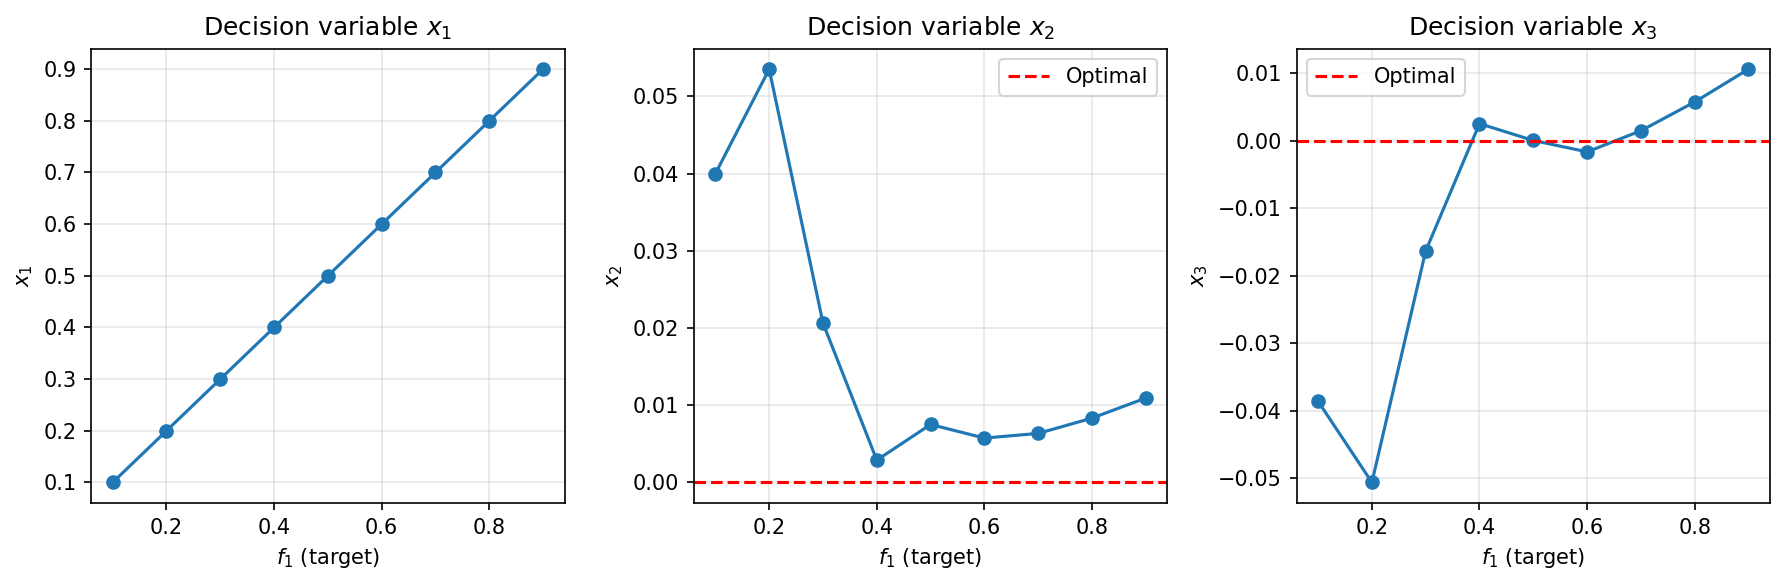

In [12]:
# Visualize decision variables along Pareto front
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(3):
    axes[i].plot(f1_targets, pareto_solutions[:, i], 'o-')
    axes[i].set_xlabel('$f_1$ (target)')
    axes[i].set_ylabel(f'$x_{i+1}$')
    axes[i].set_title(f'Decision variable $x_{i+1}$')
    axes[i].grid(True, alpha=0.3)
    
    # For ZDT1, optimal solution has x2=x3=...=0
    if i > 0:
        axes[i].axhline(0, color='r', ls='--', label='Optimal')
        axes[i].legend()

plt.tight_layout()
plt.show()

---
<a id='inverse-design'></a>
## 4. Inverse Design: Alloy Properties

Given desired material properties (e.g., yield strength, melting point), find the alloy composition.

We'll use a simplified model where properties depend on composition.

In [13]:
# Simplified alloy model: 3 components (e.g., Fe, Ni, Cr) with compositions summing to 1
# Properties are synthetic functions of composition

def alloy_properties(comp):
    """Compute yield strength and melting point from composition.
    
    comp: [Fe, Ni, Cr] fractions (sum to ~1)
    Returns: [yield_strength (MPa), melting_point (K)]
    """
    Fe, Ni, Cr = comp[:, 0], comp[:, 1], comp[:, 2]
    
    # Synthetic property models (inspired by real metallurgy)
    # Yield strength: Ni strengthens, Cr has modest effect
    yield_strength = 200 + 400*Ni + 150*Cr + 100*Fe*Ni + 50*Ni*Cr
    
    # Melting point: Fe-based, Ni lowers slightly, Cr raises
    melting_point = 1800 - 50*Ni + 100*Cr + 20*Fe*Cr
    
    return np.column_stack([yield_strength, melting_point])

# Generate composition samples (on simplex: sum to 1)
n_samples = 2000
rng = np.random.default_rng(42)
# Dirichlet sampling for compositions
compositions = rng.dirichlet([1, 1, 1], size=n_samples)

# Compute properties
properties = alloy_properties(compositions)

print(f"Compositions shape: {compositions.shape}")
print(f"Properties shape: {properties.shape}")
print(f"Yield strength range: [{properties[:, 0].min():.0f}, {properties[:, 0].max():.0f}] MPa")
print(f"Melting point range: [{properties[:, 1].min():.0f}, {properties[:, 1].max():.0f}] K")

Compositions shape: (2000, 3)
Properties shape: (2000, 2)
Yield strength range: [204, 592] MPa
Melting point range: [1754, 1896] K


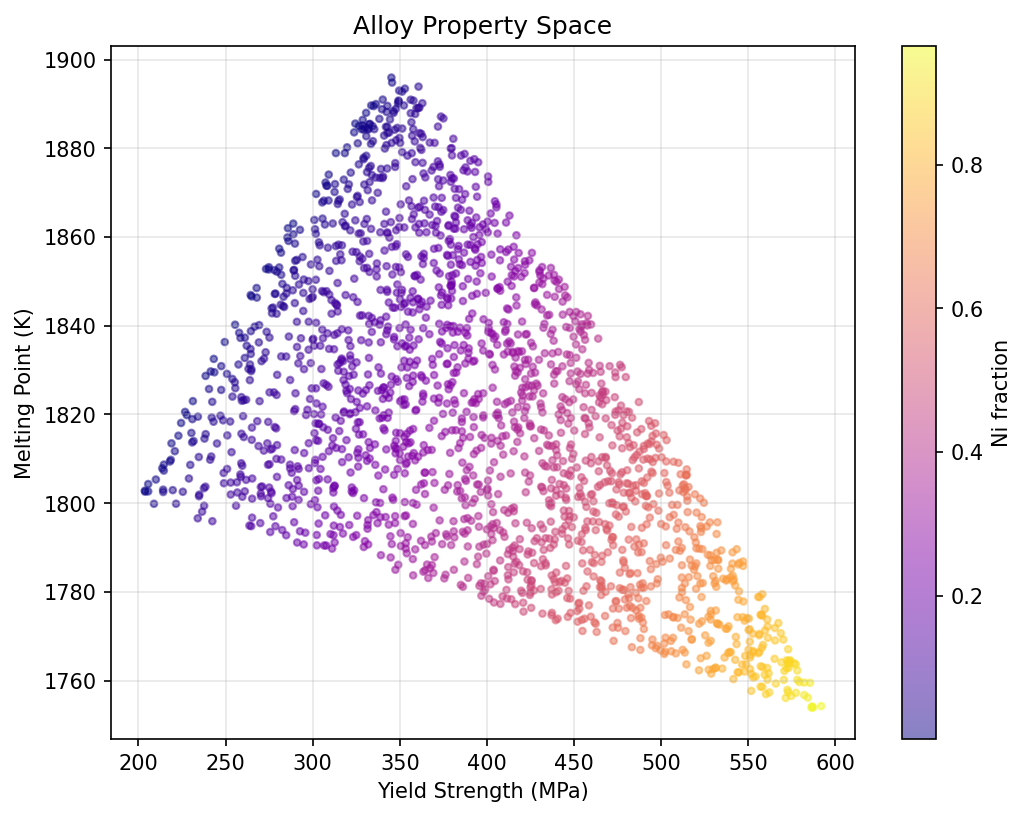

In [14]:
# Visualize property space
plt.figure(figsize=(8, 6))
scatter = plt.scatter(properties[:, 0], properties[:, 1], 
                      c=compositions[:, 1], cmap='plasma', s=10, alpha=0.5)
plt.colorbar(scatter, label='Ni fraction')
plt.xlabel('Yield Strength (MPa)')
plt.ylabel('Melting Point (K)')
plt.title('Alloy Property Space')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# Build GMM for inverse design
# Data: [Fe, Ni, Cr, yield_strength, melting_point]
data = np.column_stack([compositions, properties])

gmm_alloy = best_gmm(data)
print("GMM trained for inverse alloy design")

GMM trained for inverse alloy design


In [16]:
# Inverse design: find composition for target properties
# Target: high yield strength (500 MPa), high melting point (1850 K)

target_properties = [
    [350, 1800],  # Moderate strength, moderate melting point
    [500, 1850],  # High strength, high melting point
    [250, 1900],  # Low strength, very high melting point
]

print("Inverse Design Results:")
print("="*60)

for target in target_properties:
    # Condition on properties, predict composition
    c = gmm_alloy.condition([3, 4], [target])
    samples = c.sample(500)
    
    # Get mean composition
    comp_mean = samples[:, :3].mean(axis=0)
    comp_std = samples[:, :3].std(axis=0)
    
    # Normalize to sum to 1
    comp_mean = comp_mean / comp_mean.sum()
    
    # Verify by computing properties
    achieved = alloy_properties(comp_mean.reshape(1, -1))[0]
    
    print(f"\nTarget: Yield={target[0]} MPa, Tm={target[1]} K")
    print(f"  Composition: Fe={comp_mean[0]:.3f}, Ni={comp_mean[1]:.3f}, Cr={comp_mean[2]:.3f}")
    print(f"  Achieved:    Yield={achieved[0]:.0f} MPa, Tm={achieved[1]:.0f} K")

Inverse Design Results:

Target: Yield=350 MPa, Tm=1800 K
  Composition: Fe=0.592, Ni=0.281, Cr=0.126
  Achieved:    Yield=350 MPa, Tm=1800 K

Target: Yield=500 MPa, Tm=1850 K
  Composition: Fe=-0.191, Ni=0.454, Cr=0.737
  Achieved:    Yield=500 MPa, Tm=1848 K

Target: Yield=250 MPa, Tm=1900 K
  Composition: Fe=0.316, Ni=-0.165, Cr=0.849
  Achieved:    Yield=249 MPa, Tm=1899 K


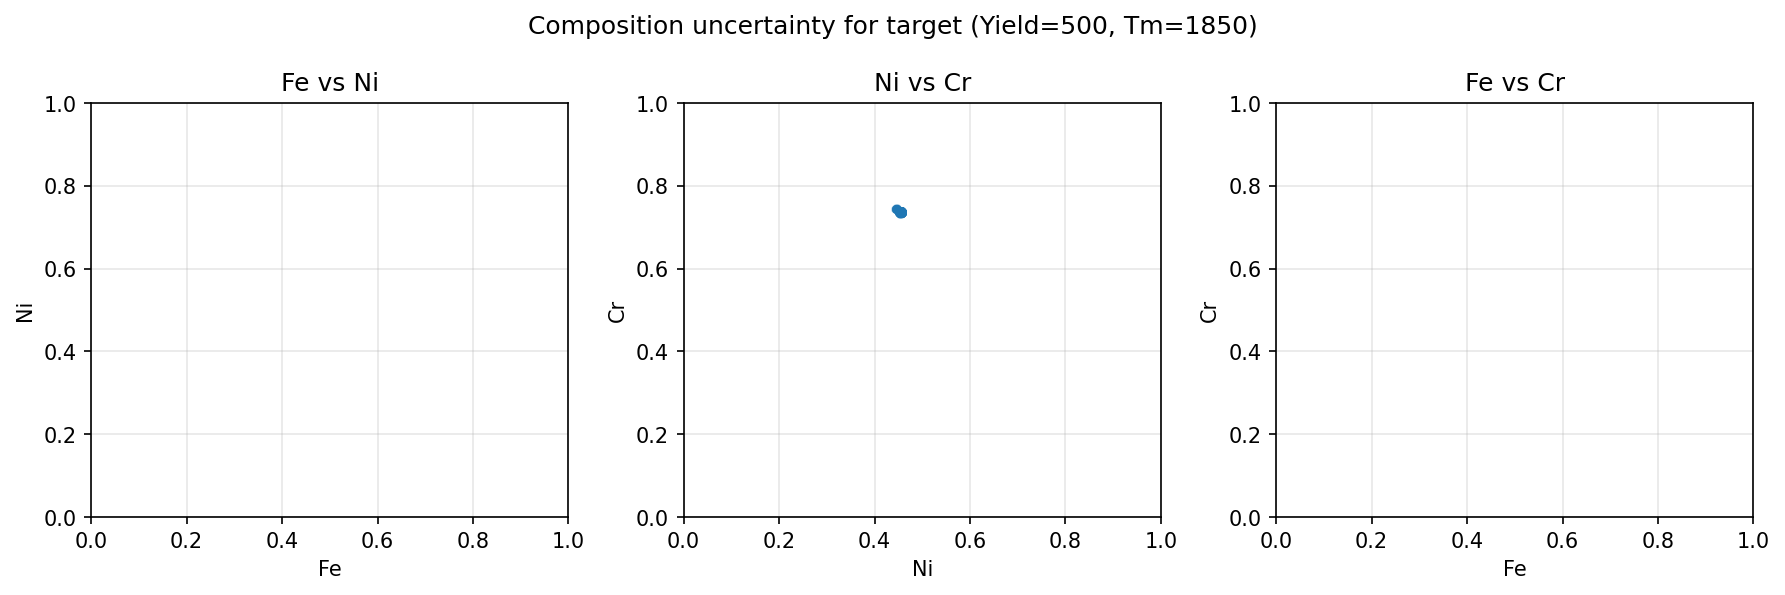

In [17]:
# Visualize composition uncertainty for one target
target = [500, 1850]
c = gmm_alloy.condition([3, 4], [target])
samples = c.sample(1000)

# Ternary-ish visualization (project to 2D)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

pairs = [(0, 1, 'Fe', 'Ni'), (1, 2, 'Ni', 'Cr'), (0, 2, 'Fe', 'Cr')]
for ax, (i, j, xi, xj) in zip(axes, pairs):
    ax.scatter(samples[:, i], samples[:, j], alpha=0.3, s=10)
    ax.set_xlabel(xi)
    ax.set_ylabel(xj)
    ax.set_title(f'{xi} vs {xj}')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Composition uncertainty for target (Yield={target[0]}, Tm={target[1]})')
plt.tight_layout()
plt.show()

---
<a id='pde'></a>
## 5. PDE-Constrained Optimization (Heat Equation)

**Inverse problem**: Given a desired steady-state temperature profile $T(x)$, find the heat source distribution $q(x)$.

The 1D steady-state heat equation: $-k \frac{d^2T}{dx^2} = q(x)$

With boundary conditions: $T(0) = T(1) = 0$

In [18]:
# Discretize heat equation with finite differences
n_points = 20  # Interior points
dx = 1.0 / (n_points + 1)
x_grid = np.linspace(dx, 1 - dx, n_points)

def solve_heat_equation(q, k=1.0):
    """Solve -k*T'' = q with T(0)=T(1)=0.
    
    Returns temperature at interior points.
    """
    n = len(q)
    dx = 1.0 / (n + 1)
    
    # Build tridiagonal matrix for -T''
    diag = 2 * np.ones(n)
    off_diag = -1 * np.ones(n - 1)
    A = np.diag(diag) + np.diag(off_diag, 1) + np.diag(off_diag, -1)
    A = k * A / dx**2
    
    # Solve A*T = q
    T = np.linalg.solve(A, q)
    return T

# Generate training data: random heat sources and resulting temperatures
n_samples = 2000
rng = np.random.default_rng(42)

# Heat sources: smooth random functions (sum of sinusoids)
q_samples = []
T_samples = []

for _ in range(n_samples):
    # Random heat source (sum of low-frequency modes)
    coeffs = rng.normal(0, 1, 5)
    q = np.zeros(n_points)
    for i, c in enumerate(coeffs):
        q += c * np.sin((i + 1) * np.pi * x_grid)
    q = q * 10  # Scale
    
    # Solve for temperature
    T = solve_heat_equation(q)
    
    q_samples.append(q)
    T_samples.append(T)

q_samples = np.array(q_samples)
T_samples = np.array(T_samples)

print(f"Heat source samples: {q_samples.shape}")
print(f"Temperature samples: {T_samples.shape}")

Heat source samples: (2000, 20)
Temperature samples: (2000, 20)


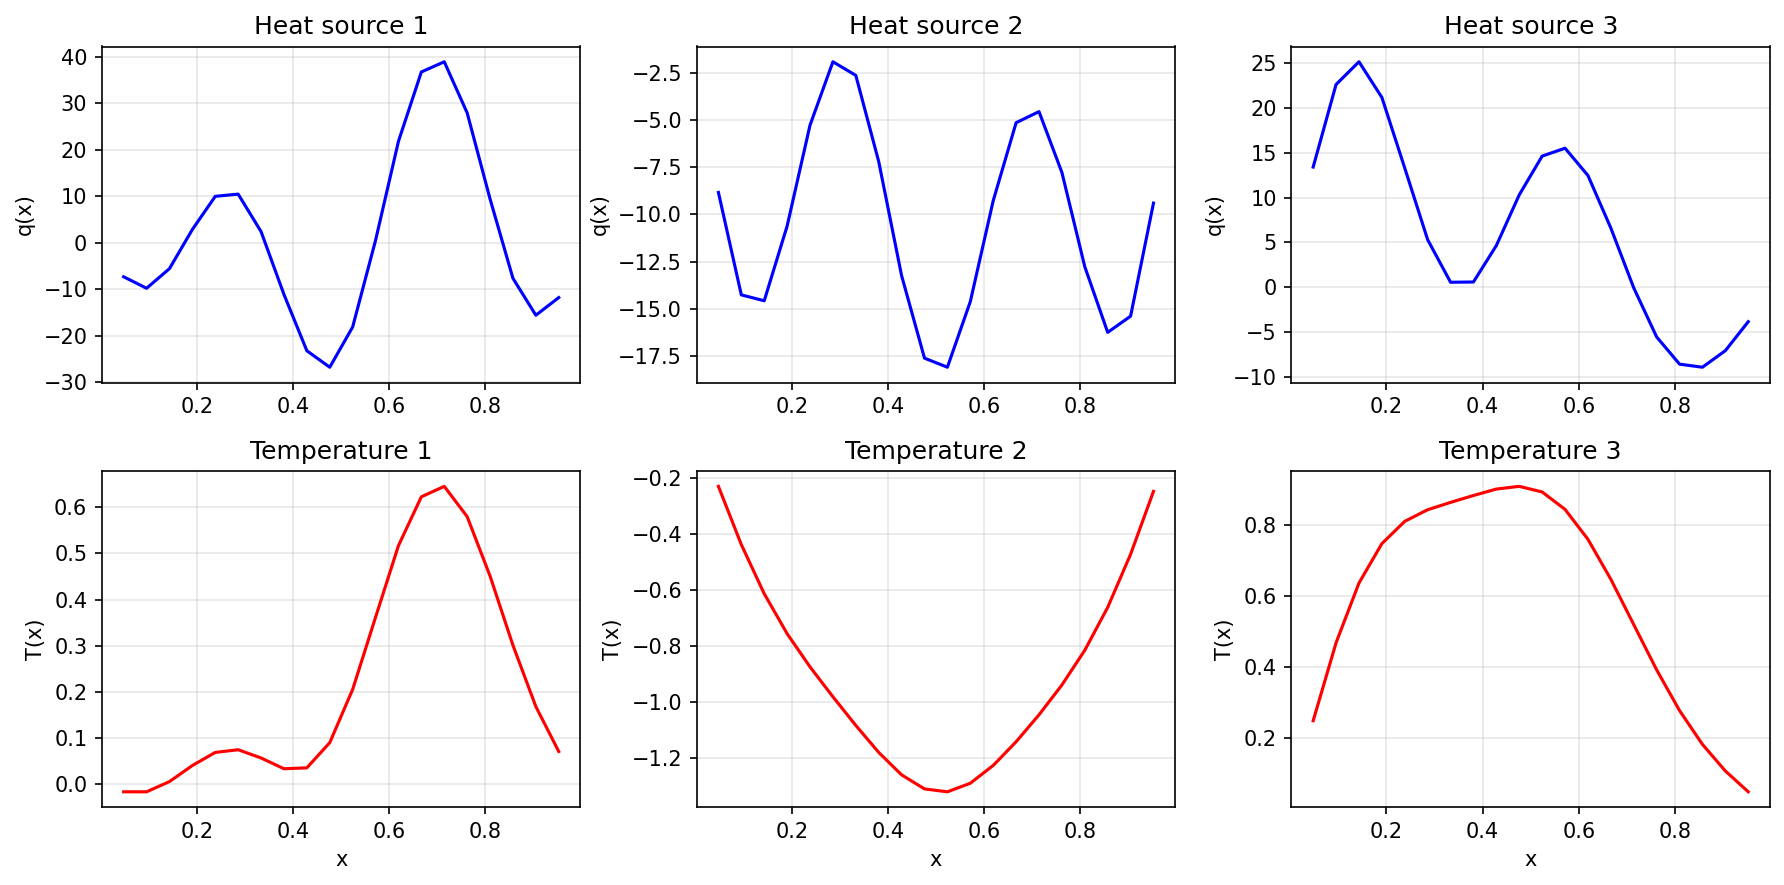

In [19]:
# Visualize some examples
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for i in range(3):
    axes[0, i].plot(x_grid, q_samples[i], 'b-')
    axes[0, i].set_ylabel('q(x)')
    axes[0, i].set_title(f'Heat source {i+1}')
    axes[0, i].grid(True, alpha=0.3)
    
    axes[1, i].plot(x_grid, T_samples[i], 'r-')
    axes[1, i].set_xlabel('x')
    axes[1, i].set_ylabel('T(x)')
    axes[1, i].set_title(f'Temperature {i+1}')
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Reduce dimensionality using PCA for GMM
from sklearn.decomposition import PCA

n_components = 5  # Number of modes to keep

pca_q = PCA(n_components=n_components)
pca_T = PCA(n_components=n_components)

q_reduced = pca_q.fit_transform(q_samples)
T_reduced = pca_T.fit_transform(T_samples)

print(f"Explained variance (q): {pca_q.explained_variance_ratio_.sum():.3f}")
print(f"Explained variance (T): {pca_T.explained_variance_ratio_.sum():.3f}")

Explained variance (q): 1.000
Explained variance (T): 1.000


In [21]:
# Build GMM in reduced space
# Data: [q_modes, T_modes]
data_pde = np.column_stack([q_reduced, T_reduced])
gmm_heat = best_gmm(data_pde)
print("GMM trained for heat equation inverse problem")

GMM trained for heat equation inverse problem


In [22]:
# Inverse problem: given target temperature, find heat source
# Target: parabolic temperature profile (maximum at center)
T_target = 4 * x_grid * (1 - x_grid)  # Parabola with max at x=0.5
T_target = T_target * 5  # Scale

# Project to reduced space
T_target_reduced = pca_T.transform(T_target.reshape(1, -1))

# Condition on temperature, generate heat source
T_cols = list(range(n_components, 2*n_components))
pred = gmm_heat.predict(T_cols, T_target_reduced)

# Reconstruct heat source
q_pred = pca_q.inverse_transform(pred.reshape(1, -1))[0]

# Verify by solving forward problem
T_achieved = solve_heat_equation(q_pred)

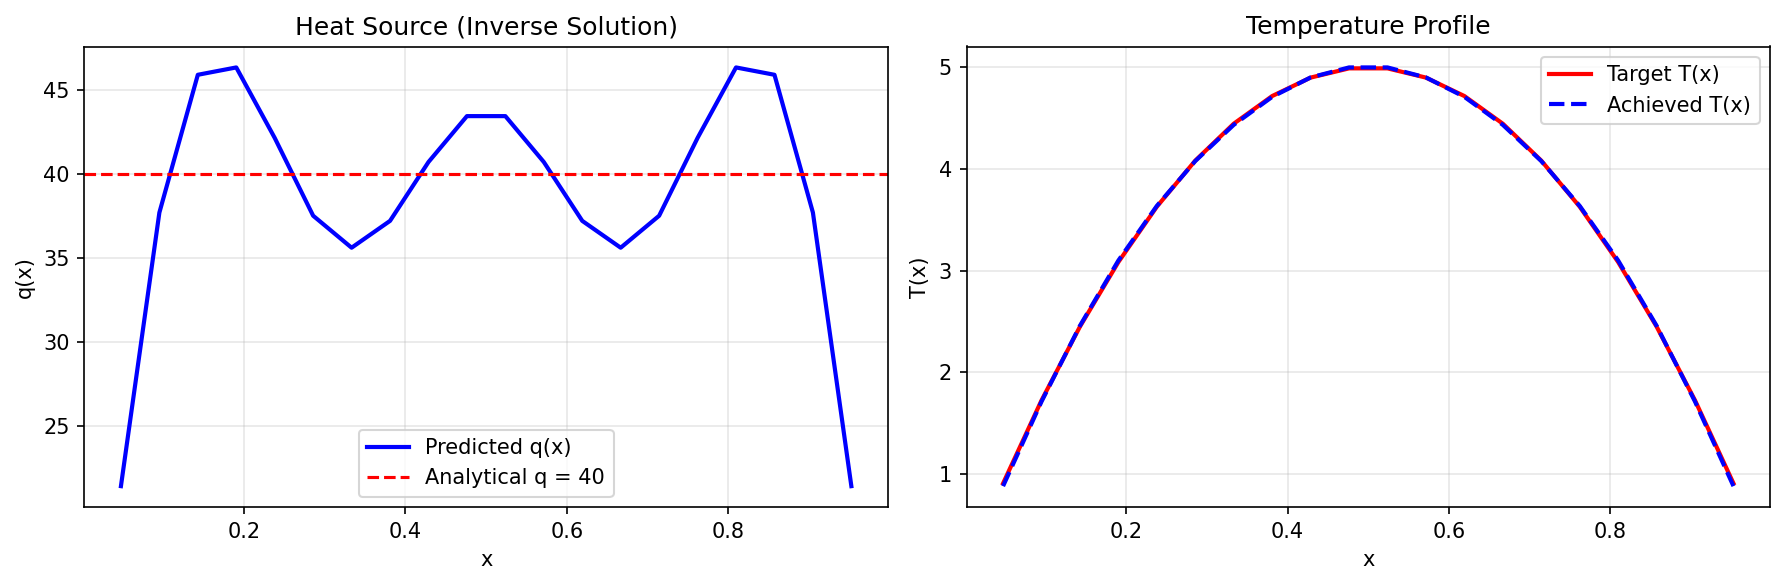

Temperature MAE: 0.0105


In [23]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_grid, q_pred, 'b-', lw=2, label='Predicted q(x)')
# Analytical solution for parabolic T: q = 8 (constant)
axes[0].axhline(8*5, color='r', ls='--', label='Analytical q = 40')
axes[0].set_xlabel('x')
axes[0].set_ylabel('q(x)')
axes[0].set_title('Heat Source (Inverse Solution)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_grid, T_target, 'r-', lw=2, label='Target T(x)')
axes[1].plot(x_grid, T_achieved, 'b--', lw=2, label='Achieved T(x)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('T(x)')
axes[1].set_title('Temperature Profile')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Error
mae = np.mean(np.abs(T_target - T_achieved))
print(f"Temperature MAE: {mae:.4f}")

---
<a id='trajectory'></a>
## 6. Trajectory Optimization / Optimal Control

Find control inputs $u(t)$ that drive a system from initial state to target final state.

**System**: Simple 1D dynamics $\ddot{x} = u$ (double integrator)

**Goal**: Drive from $(x_0, v_0) = (0, 0)$ to $(x_f, v_f)$ in fixed time $T$.

In [24]:
# Double integrator dynamics
# State: [x, v], Control: u
# dx/dt = v, dv/dt = u

T_final = 1.0  # Final time
n_control_points = 10  # Parameterize control with spline control points
t_control = np.linspace(0, T_final, n_control_points)

def simulate_trajectory(u_points, x0=0, v0=0):
    """Simulate trajectory given control point values."""
    # Interpolate control
    u_interp = interp1d(t_control, u_points, kind='cubic', fill_value='extrapolate')
    
    def dynamics(t, state):
        x, v = state
        u = u_interp(t)
        return [v, u]
    
    # Simulate
    t_eval = np.linspace(0, T_final, 50)
    sol = solve_ivp(dynamics, [0, T_final], [x0, v0], t_eval=t_eval)
    
    return sol.t, sol.y[0], sol.y[1]  # t, x, v

# Generate training data: random control inputs and resulting final states
n_samples = 2000
rng = np.random.default_rng(42)

u_samples = []
final_states = []

for _ in range(n_samples):
    # Random smooth control (bounded)
    u_points = rng.uniform(-5, 5, n_control_points)
    # Smooth by averaging neighbors
    u_points = np.convolve(u_points, [0.25, 0.5, 0.25], mode='same')
    
    # Simulate
    t, x, v = simulate_trajectory(u_points)
    
    u_samples.append(u_points)
    final_states.append([x[-1], v[-1]])

u_samples = np.array(u_samples)
final_states = np.array(final_states)

print(f"Control samples: {u_samples.shape}")
print(f"Final states: {final_states.shape}")
print(f"Final position range: [{final_states[:, 0].min():.2f}, {final_states[:, 0].max():.2f}]")
print(f"Final velocity range: [{final_states[:, 1].min():.2f}, {final_states[:, 1].max():.2f}]")

Control samples: (2000, 10)
Final states: (2000, 2)
Final position range: [-1.64, 1.63]
Final velocity range: [-3.05, 3.08]


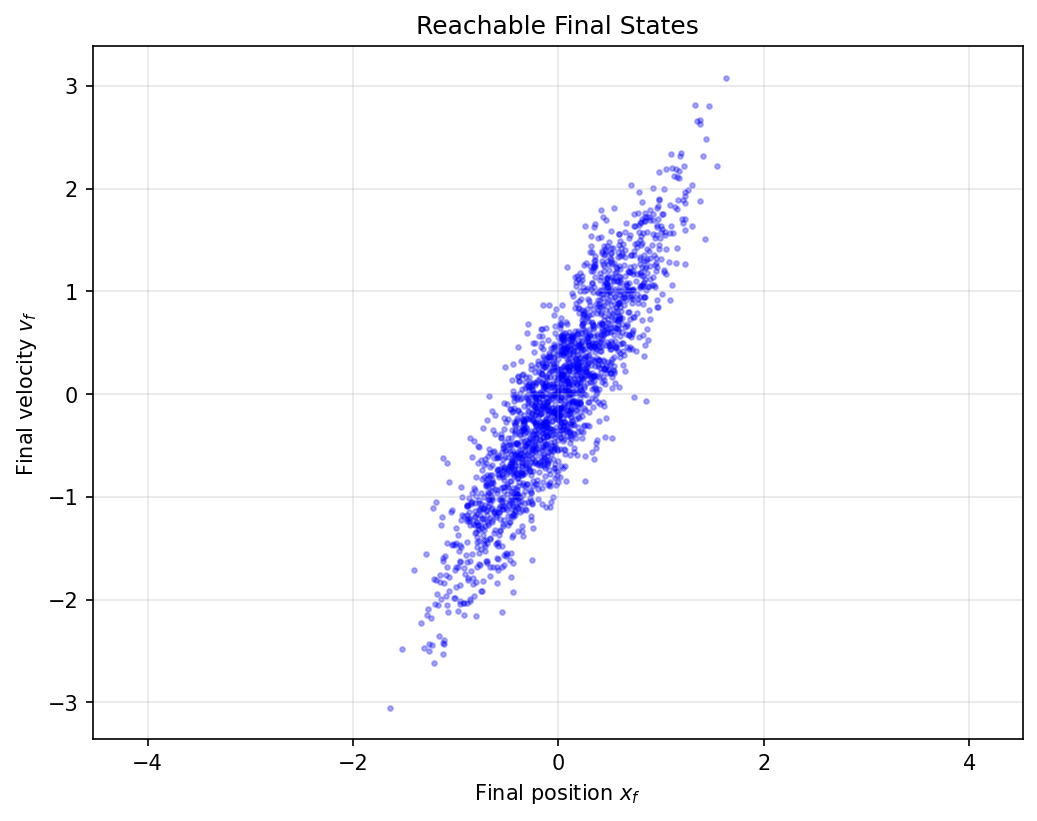

In [25]:
# Visualize reachable set
plt.figure(figsize=(8, 6))
plt.scatter(final_states[:, 0], final_states[:, 1], c='blue', s=5, alpha=0.3)
plt.xlabel('Final position $x_f$')
plt.ylabel('Final velocity $v_f$')
plt.title('Reachable Final States')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

In [26]:
# Build GMM: generate control given desired final state
data_traj = np.column_stack([u_samples, final_states])
gmm_traj = best_gmm(data_traj)
print("GMM trained for trajectory optimization")

GMM trained for trajectory optimization


Target: x=1.0, v=0.0 -> Achieved: x=1.001, v=0.004
Target: x=0.5, v=1.0 -> Achieved: x=0.501, v=1.002
Target: x=-0.5, v=0.5 -> Achieved: x=-0.501, v=0.499


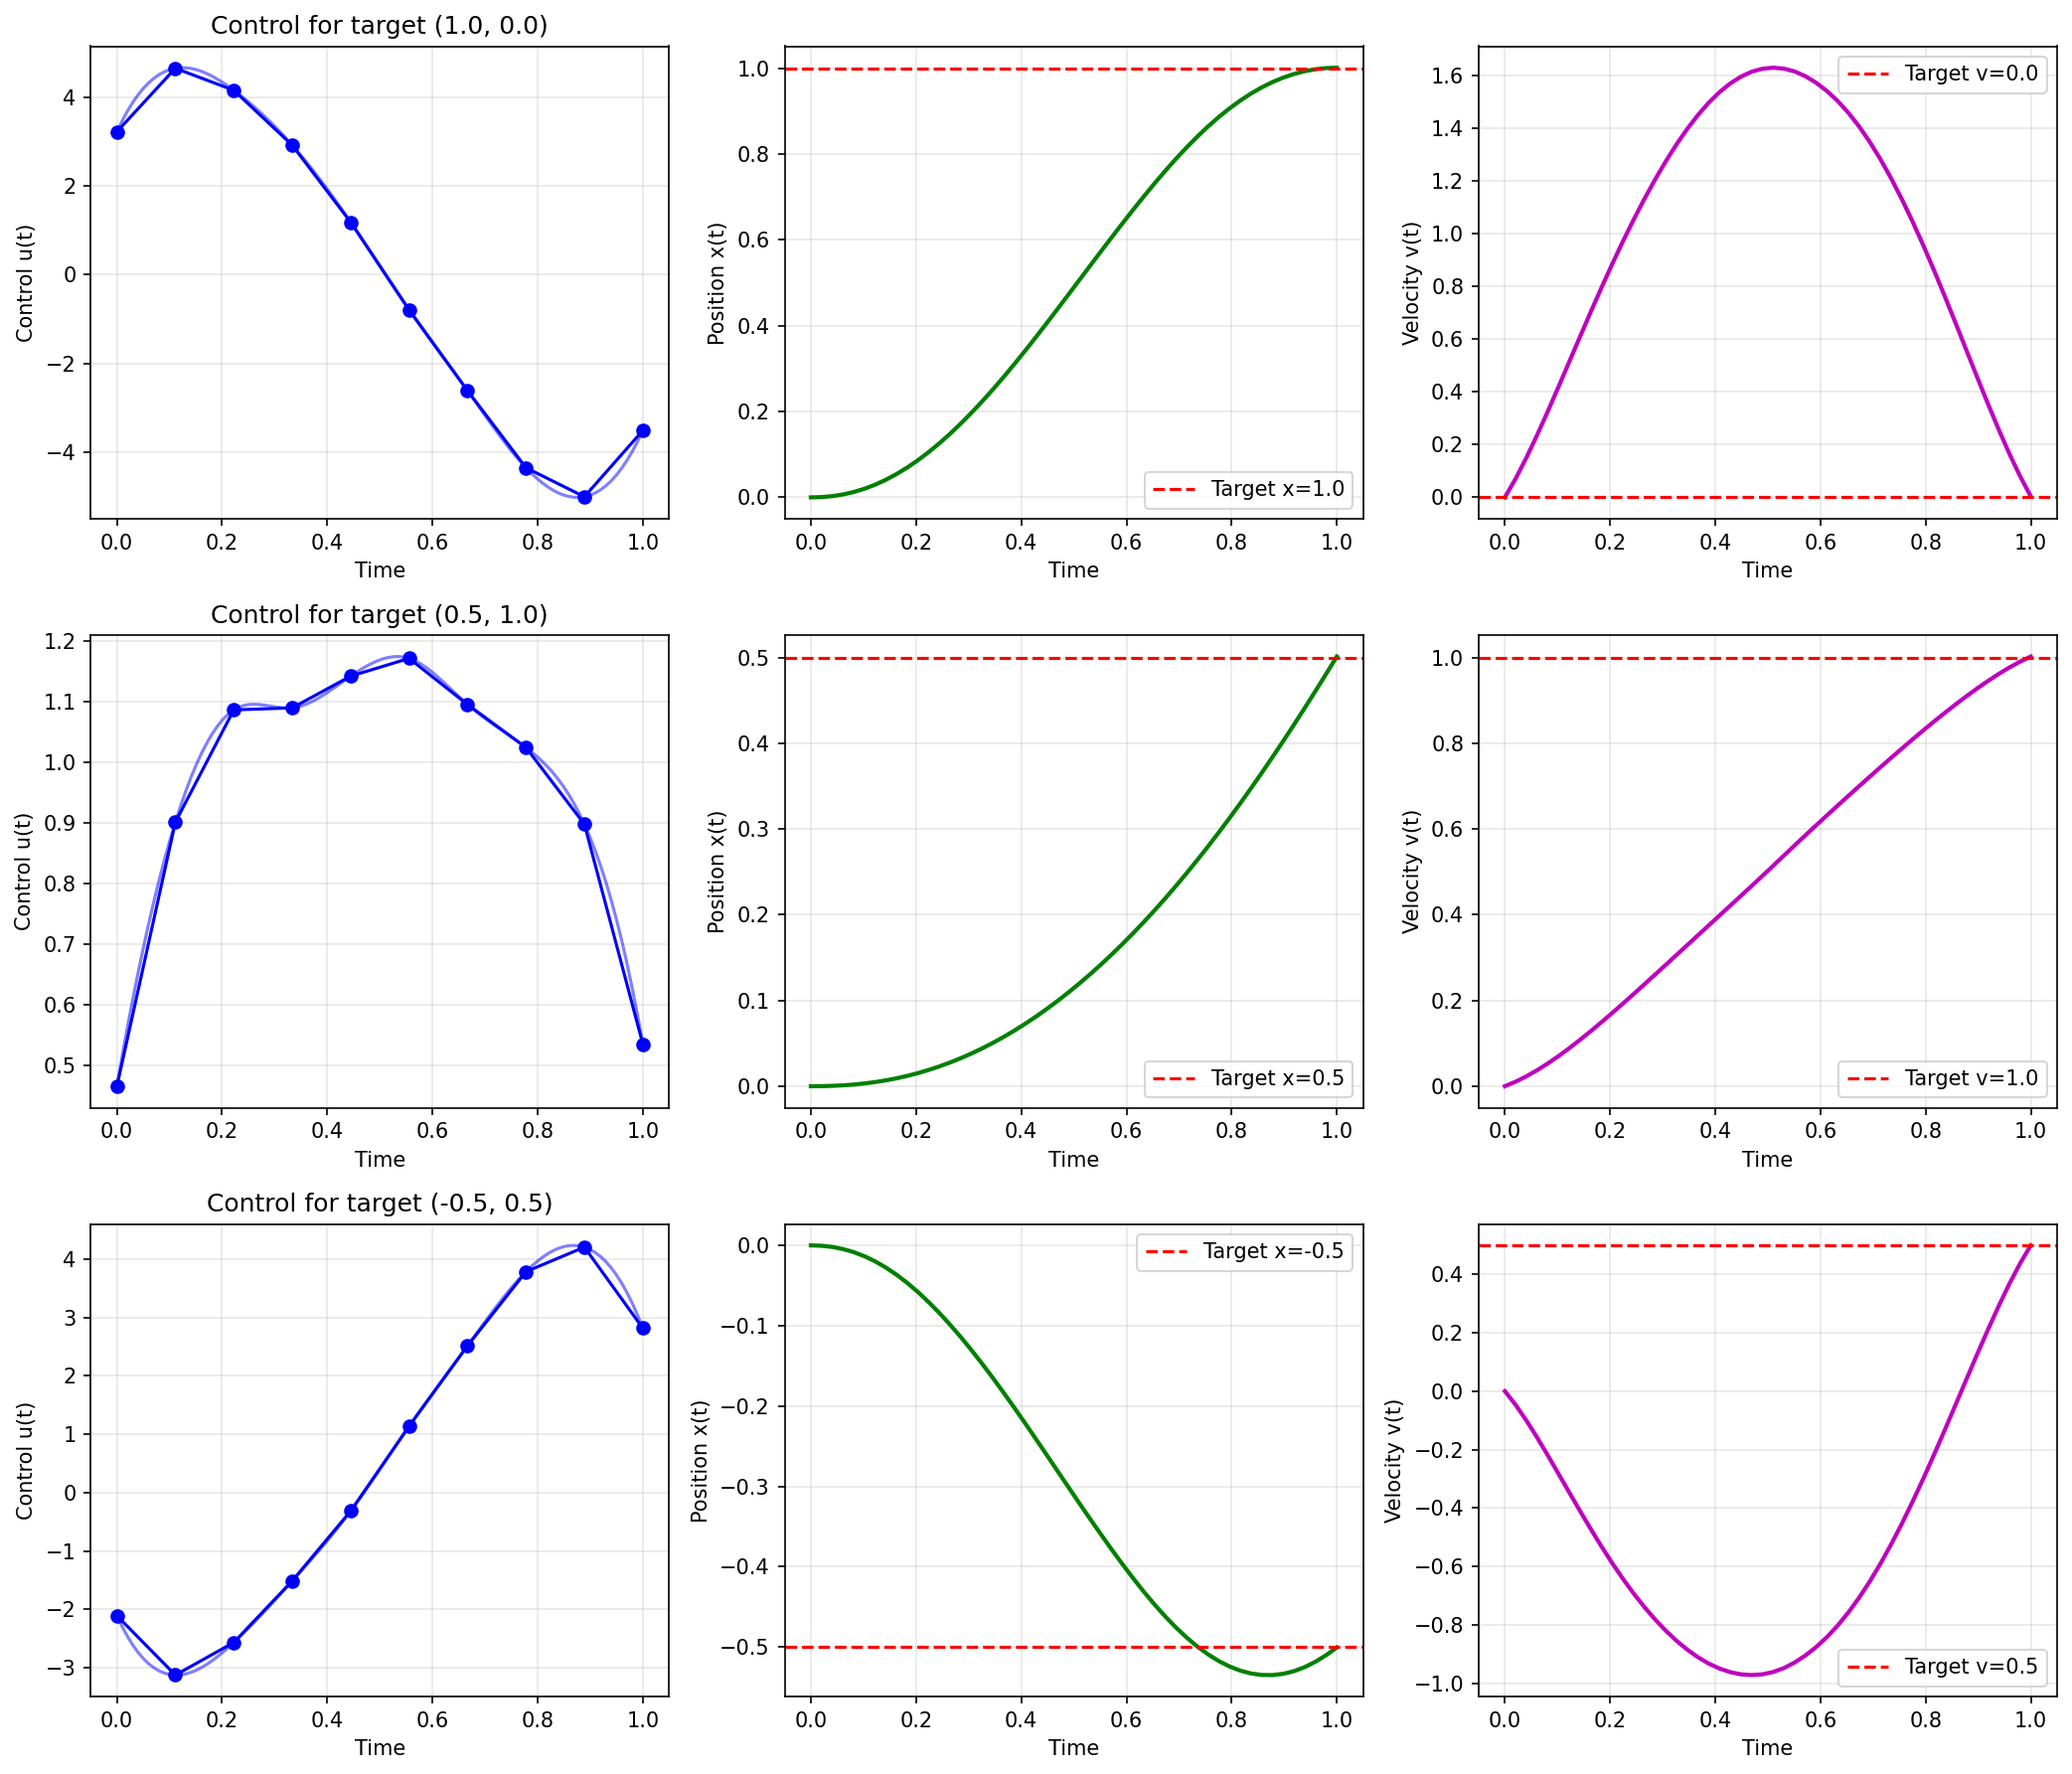

In [27]:
# Inverse problem: find control for desired final state
targets = [
    [1.0, 0.0],   # Move to x=1, stop
    [0.5, 1.0],   # Move to x=0.5 with velocity 1
    [-0.5, 0.5],  # Move backward with positive velocity
]

fig, axes = plt.subplots(len(targets), 3, figsize=(14, 4*len(targets)))

for i, target in enumerate(targets):
    # Condition on final state, predict control points
    # Data columns: [u0, u1, ..., u9, x_final, v_final]
    # Condition on columns [10, 11] (final state), predict columns [0-9] (control)
    final_cols = [n_control_points, n_control_points + 1]
    pred = gmm_traj.predict(final_cols, np.array([target]))
    # pred has shape (1, n_control_points) - extract the single row
    u_pred = pred[0]
    
    # Simulate
    t, x, v = simulate_trajectory(u_pred)
    
    # Plot control
    axes[i, 0].plot(t_control, u_pred, 'bo-', label='Control points')
    u_interp = interp1d(t_control, u_pred, kind='cubic')
    t_fine = np.linspace(0, T_final, 100)
    axes[i, 0].plot(t_fine, u_interp(t_fine), 'b-', alpha=0.5)
    axes[i, 0].set_xlabel('Time')
    axes[i, 0].set_ylabel('Control u(t)')
    axes[i, 0].set_title(f'Control for target ({target[0]}, {target[1]})')
    axes[i, 0].grid(True, alpha=0.3)
    
    # Plot position
    axes[i, 1].plot(t, x, 'g-', lw=2)
    axes[i, 1].axhline(target[0], color='r', ls='--', label=f'Target x={target[0]}')
    axes[i, 1].set_xlabel('Time')
    axes[i, 1].set_ylabel('Position x(t)')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)
    
    # Plot velocity
    axes[i, 2].plot(t, v, 'm-', lw=2)
    axes[i, 2].axhline(target[1], color='r', ls='--', label=f'Target v={target[1]}')
    axes[i, 2].set_xlabel('Time')
    axes[i, 2].set_ylabel('Velocity v(t)')
    axes[i, 2].legend()
    axes[i, 2].grid(True, alpha=0.3)
    
    print(f"Target: x={target[0]}, v={target[1]} -> Achieved: x={x[-1]:.3f}, v={v[-1]:.3f}")

plt.tight_layout()
plt.show()

---
<a id='robust'></a>
## 7. Robust Optimization Under Uncertainty

Find solutions that perform well across uncertain parameters.

**Problem**: Design x to minimize worst-case cost over uncertain θ:
$$\min_x \max_\theta f(x, \theta)$$

We'll use a simple example where the objective depends on both design and uncertainty.

In [28]:
# Robust optimization example
# f(x, θ) = (x - θ)² + 0.1*x²
# θ ∈ [-1, 1] is uncertain
# Optimal robust solution: x that minimizes max over θ

def objective(x, theta):
    return (x - theta)**2 + 0.1*x**2

def worst_case_cost(x, theta_range=[-1, 1]):
    """Compute worst-case (maximum) cost over theta range."""
    # For this simple problem, worst case is at boundary
    costs = [objective(x, theta_range[0]), objective(x, theta_range[1])]
    return max(costs)

# Generate data: sample (x, θ) and compute cost
n_samples = 5000
x_samples = np.random.uniform(-2, 2, n_samples)
theta_samples = np.random.uniform(-1, 1, n_samples)
costs = objective(x_samples, theta_samples)

# Also compute statistics over θ for each x
x_unique = np.linspace(-2, 2, 100)
theta_grid = np.linspace(-1, 1, 50)

mean_costs = []
max_costs = []
for x in x_unique:
    c = objective(x, theta_grid)
    mean_costs.append(c.mean())
    max_costs.append(c.max())

mean_costs = np.array(mean_costs)
max_costs = np.array(max_costs)

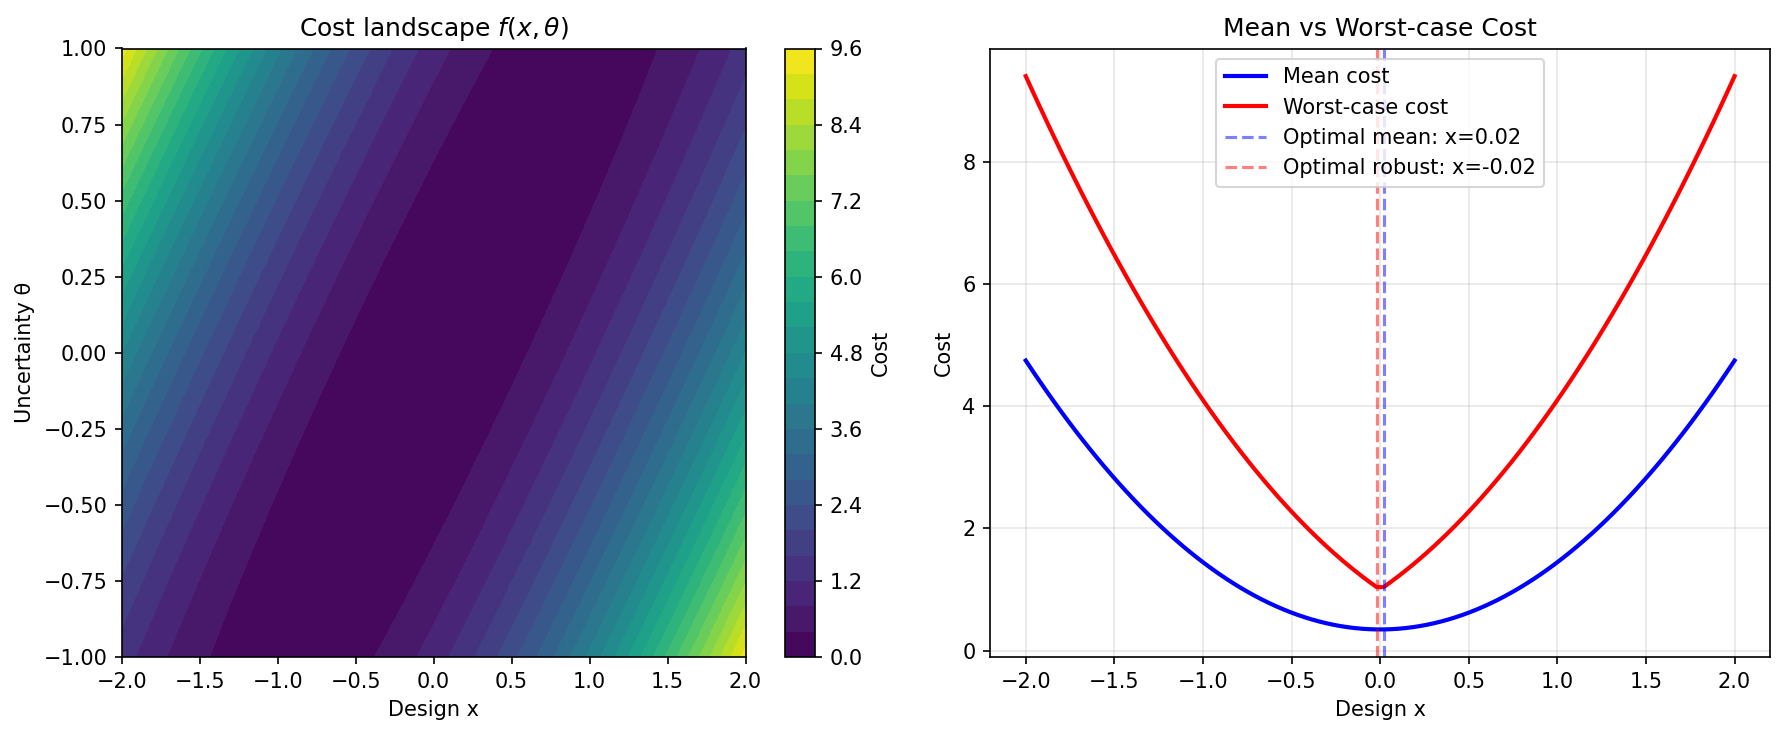

In [29]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: cost surface
X_grid, Theta_grid = np.meshgrid(x_unique, theta_grid)
Cost_grid = objective(X_grid, Theta_grid)
c = axes[0].contourf(X_grid, Theta_grid, Cost_grid, levels=30, cmap='viridis')
plt.colorbar(c, ax=axes[0], label='Cost')
axes[0].set_xlabel('Design x')
axes[0].set_ylabel('Uncertainty θ')
axes[0].set_title('Cost landscape $f(x, \\theta)$')

# Right: mean and worst-case cost vs x
axes[1].plot(x_unique, mean_costs, 'b-', lw=2, label='Mean cost')
axes[1].plot(x_unique, max_costs, 'r-', lw=2, label='Worst-case cost')

# Optimal points
x_opt_mean = x_unique[np.argmin(mean_costs)]
x_opt_robust = x_unique[np.argmin(max_costs)]
axes[1].axvline(x_opt_mean, color='b', ls='--', alpha=0.5, label=f'Optimal mean: x={x_opt_mean:.2f}')
axes[1].axvline(x_opt_robust, color='r', ls='--', alpha=0.5, label=f'Optimal robust: x={x_opt_robust:.2f}')

axes[1].set_xlabel('Design x')
axes[1].set_ylabel('Cost')
axes[1].set_title('Mean vs Worst-case Cost')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# Build GMM for robust optimization
# Include worst-case cost in data
# For each sample, compute its worst-case cost
wc_costs = np.array([worst_case_cost(x) for x in x_samples])

# Data: [x, θ, cost, worst_case_cost]
data_robust = np.column_stack([x_samples, theta_samples, costs, wc_costs])

gmm_robust = best_gmm(data_robust)
print("GMM trained for robust optimization")

GMM trained for robust optimization


In [31]:
# Find robust optimal design by conditioning on low worst-case cost
# Condition on worst_case_cost being low
target_wc = min_costs = np.percentile(wc_costs, 5)  # Target 5th percentile

c = gmm_robust.condition([3], [[target_wc]])
samples = c.sample(1000)

x_robust_samples = samples[:, 0]

print(f"Target worst-case cost: {target_wc:.3f}")
print(f"Robust design x: {x_robust_samples.mean():.3f} ± {x_robust_samples.std():.3f}")
print(f"Analytical optimal (for this problem): x ≈ 0")

Target worst-case cost: 1.211
Robust design x: 0.028 ± 0.094
Analytical optimal (for this problem): x ≈ 0


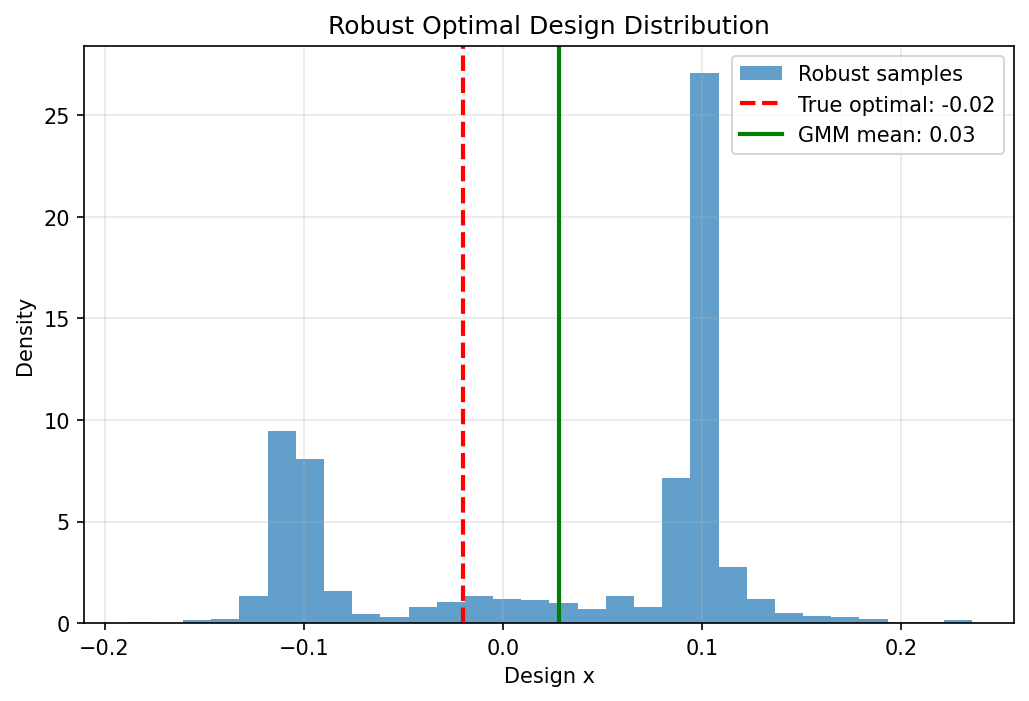

In [32]:
# Visualize
plt.figure(figsize=(8, 5))
plt.hist(x_robust_samples, bins=30, density=True, alpha=0.7, label='Robust samples')
plt.axvline(x_opt_robust, color='r', ls='--', lw=2, label=f'True optimal: {x_opt_robust:.2f}')
plt.axvline(x_robust_samples.mean(), color='g', ls='-', lw=2, label=f'GMM mean: {x_robust_samples.mean():.2f}')
plt.xlabel('Design x')
plt.ylabel('Density')
plt.title('Robust Optimal Design Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
<a id='facility'></a>
## 8. Facility Location Problem

Place N facilities to minimize total weighted distance to demand points.

**Continuous relaxation**: Facility locations are continuous variables.

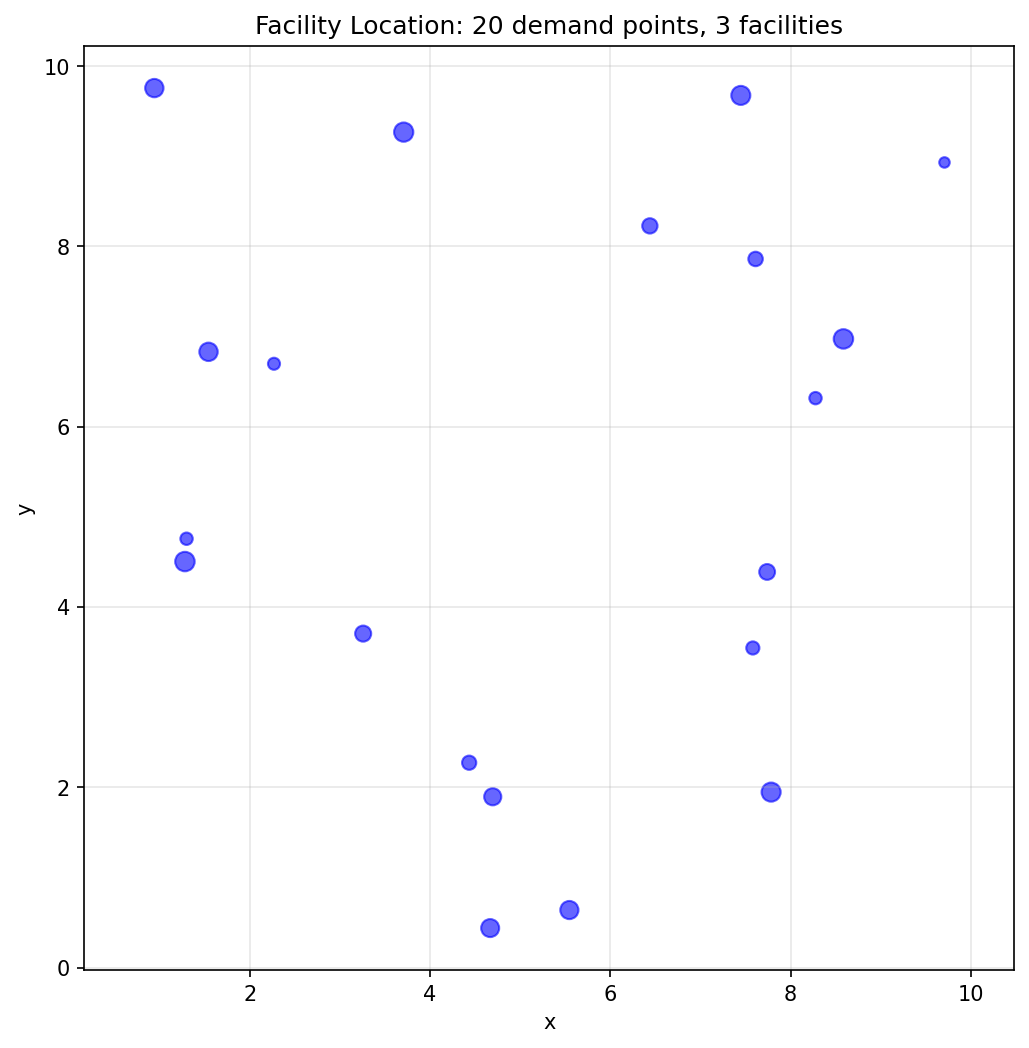

In [33]:
# Generate demand points
n_demand = 20
rng = np.random.default_rng(42)
demand_points = rng.uniform(0, 10, (n_demand, 2))
demand_weights = rng.uniform(0.5, 2, n_demand)

# Number of facilities to place
n_facilities = 3

def total_cost(facility_locations, demand_points, weights):
    """Compute total weighted distance to nearest facility."""
    facilities = facility_locations.reshape(-1, 2)
    total = 0
    for i, (dp, w) in enumerate(zip(demand_points, weights)):
        # Distance to each facility
        dists = np.sqrt(((facilities - dp)**2).sum(axis=1))
        total += w * dists.min()  # Distance to nearest
    return total

# Visualize demand points
plt.figure(figsize=(8, 8))
plt.scatter(demand_points[:, 0], demand_points[:, 1], 
            s=demand_weights*50, c='blue', alpha=0.6, label='Demand points')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Facility Location: {n_demand} demand points, {n_facilities} facilities')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
# Generate training data: random facility locations and resulting costs
n_samples = 5000

facility_samples = []
cost_samples = []

for _ in range(n_samples):
    # Random facility locations
    locs = rng.uniform(0, 10, n_facilities * 2)
    cost = total_cost(locs, demand_points, demand_weights)
    
    facility_samples.append(locs)
    cost_samples.append(cost)

facility_samples = np.array(facility_samples)
cost_samples = np.array(cost_samples)

print(f"Cost range: [{cost_samples.min():.2f}, {cost_samples.max():.2f}]")

Cost range: [47.87, 154.42]


In [35]:
# Build GMM
data_facility = np.column_stack([facility_samples, cost_samples])
gmm_facility = best_gmm(data_facility)
print("GMM trained for facility location")

GMM trained for facility location


In [36]:
# Find optimal locations by conditioning on low cost
target_cost = np.percentile(cost_samples, 1)  # Target 1st percentile

c = gmm_facility.condition([n_facilities * 2], [[target_cost]])
samples = c.sample(500)

# Get mean solution
opt_locs = samples[:, :n_facilities*2].mean(axis=0).reshape(n_facilities, 2)
opt_cost = total_cost(opt_locs.flatten(), demand_points, demand_weights)

print(f"Target cost: {target_cost:.2f}")
print(f"Achieved cost: {opt_cost:.2f}")
print(f"Optimal locations: {opt_locs}")

Target cost: 54.52
Achieved cost: 91.25
Optimal locations: [[5.21977688 5.35692559]
 [4.99281516 5.00568813]
 [4.60909636 5.9026003 ]]


In [37]:
# Compare with scipy optimizer
from scipy.optimize import minimize

result = minimize(
    lambda x: total_cost(x, demand_points, demand_weights),
    x0=rng.uniform(0, 10, n_facilities * 2),
    method='L-BFGS-B',
    bounds=[(0, 10)] * (n_facilities * 2)
)

scipy_locs = result.x.reshape(n_facilities, 2)
scipy_cost = result.fun

print(f"\nScipy optimization:")
print(f"  Cost: {scipy_cost:.2f}")
print(f"  Locations: {scipy_locs}")


Scipy optimization:
  Cost: 44.74
  Locations: [[1.5428953  6.83048939]
 [7.76855365 7.70520517]
 [5.00336561 1.71745612]]


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


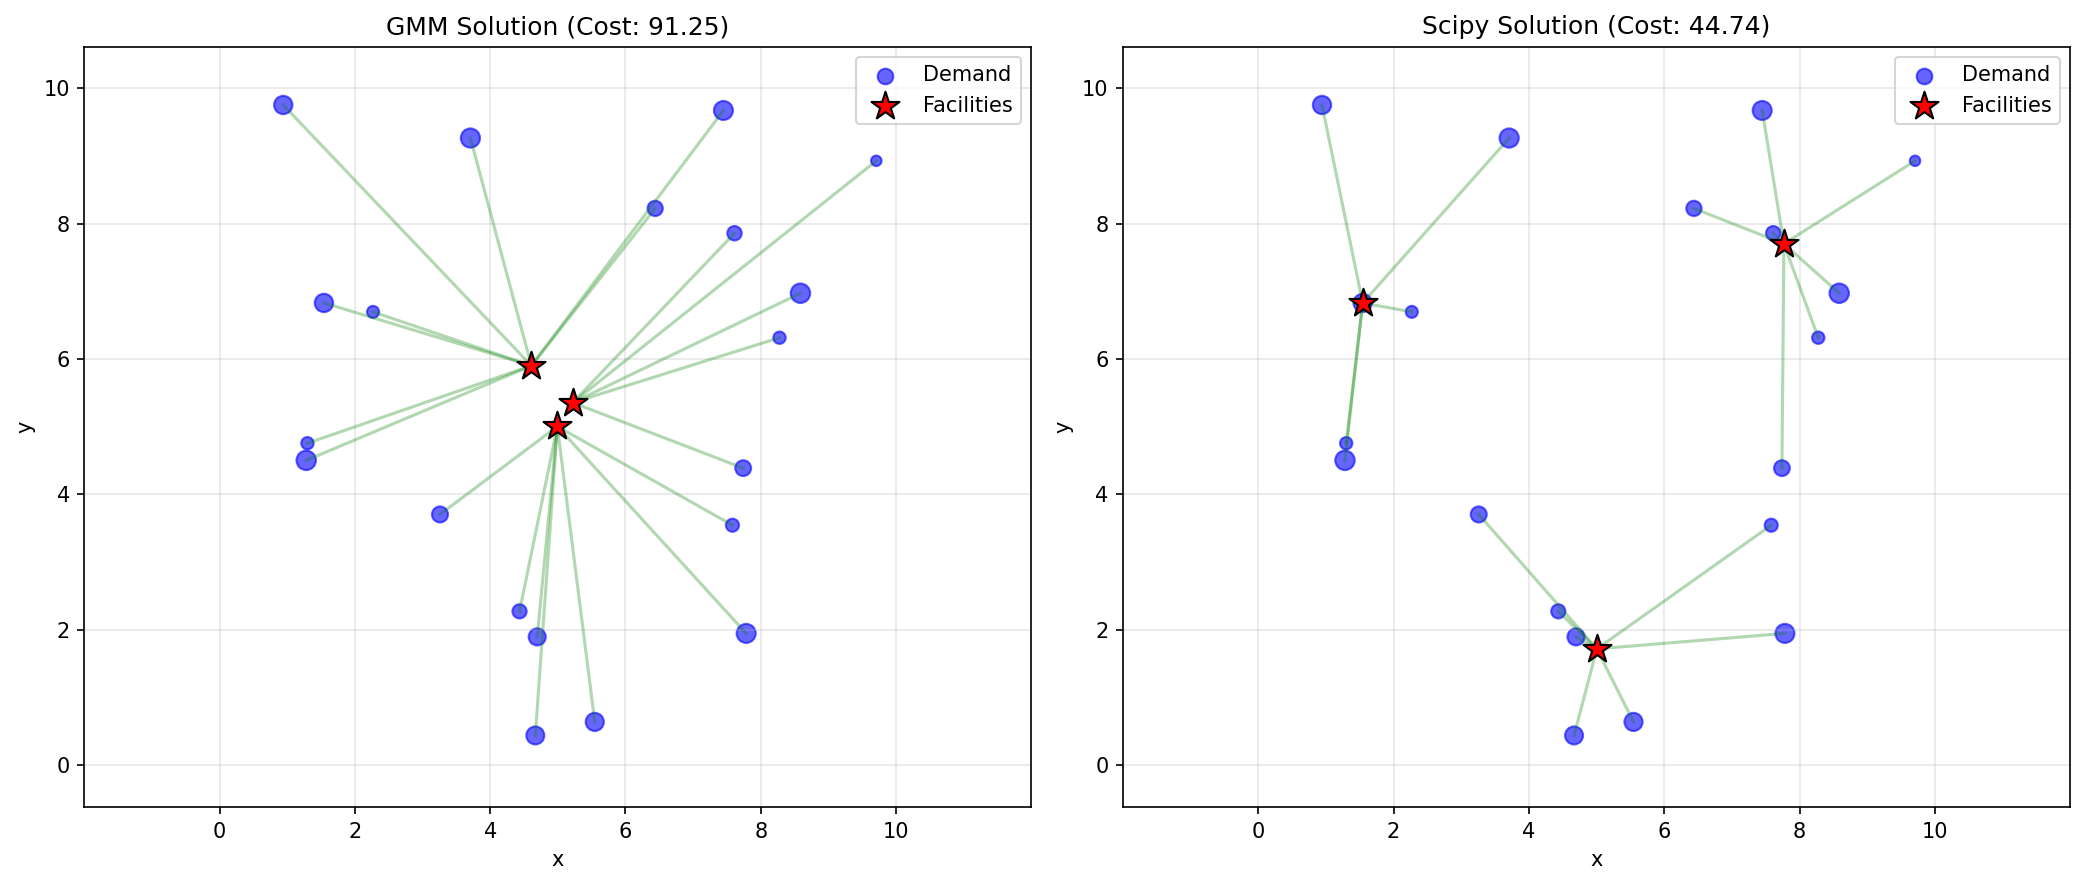

In [38]:
# Visualize solutions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, locs, title, cost in [
    (axes[0], opt_locs, 'GMM Solution', opt_cost),
    (axes[1], scipy_locs, 'Scipy Solution', scipy_cost)
]:
    ax.scatter(demand_points[:, 0], demand_points[:, 1], 
               s=demand_weights*50, c='blue', alpha=0.6, label='Demand')
    ax.scatter(locs[:, 0], locs[:, 1], 
               s=200, c='red', marker='*', edgecolors='black',
               label='Facilities', zorder=5)
    
    # Draw lines to nearest facility
    for dp in demand_points:
        dists = np.sqrt(((locs - dp)**2).sum(axis=1))
        nearest = locs[np.argmin(dists)]
        ax.plot([dp[0], nearest[0]], [dp[1], nearest[1]], 'g-', alpha=0.3)
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'{title} (Cost: {cost:.2f})')
    ax.legend()
    ax.axis('equal')
    ax.set_xlim(-1, 11)
    ax.set_ylim(-1, 11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
<a id='eos'></a>
## 9. Equation of State Fitting

Fit van der Waals equation of state parameters from PVT data.

$$P = \frac{RT}{V - b} - \frac{a}{V^2}$$

Given experimental (P, V, T) data, find parameters (a, b).

In [39]:
# Van der Waals equation
R = 8.314  # J/(mol·K)

def vdw_pressure(V, T, a, b):
    """Compute pressure from van der Waals equation."""
    return R * T / (V - b) - a / V**2

# True parameters (for CO2-like gas)
a_true = 0.364  # Pa·m⁶/mol²
b_true = 4.27e-5  # m³/mol

# Generate synthetic experimental data
n_data = 50
V_data = np.random.uniform(1e-4, 5e-4, n_data)  # m³/mol
T_data = np.random.uniform(300, 500, n_data)  # K
P_data = vdw_pressure(V_data, T_data, a_true, b_true)

# Add noise
P_data += np.random.normal(0, P_data * 0.02)  # 2% noise

print(f"True parameters: a = {a_true:.4f}, b = {b_true:.2e}")
print(f"P range: [{P_data.min()/1e6:.2f}, {P_data.max()/1e6:.2f}] MPa")

True parameters: a = 0.3640, b = 4.27e-05
P range: [4.39, 21.51] MPa


In [40]:
# Generate training data: sample (a, b) and compute pressures
n_samples = 3000

# Sample parameters around reasonable range
a_samples = np.random.uniform(0.1, 0.8, n_samples)
b_samples = np.random.uniform(1e-5, 1e-4, n_samples)

# For each (a,b), compute pressure at several (V,T) points
# Use representative V, T values
V_repr = np.array([1.5e-4, 2.5e-4, 3.5e-4])  # 3 representative V values
T_repr = np.array([350, 400, 450])  # 3 representative T values

# Compute pressures for all combinations
P_samples = []
for a, b in zip(a_samples, b_samples):
    P_vals = []
    for V, T in zip(V_repr, T_repr):
        try:
            P = vdw_pressure(V, T, a, b)
            P_vals.append(P / 1e6)  # Convert to MPa
        except:
            P_vals.append(np.nan)
    P_samples.append(P_vals)

P_samples = np.array(P_samples)

# Remove invalid samples
valid = ~np.isnan(P_samples).any(axis=1) & (P_samples > 0).all(axis=1)
a_samples = a_samples[valid]
b_samples = b_samples[valid]
P_samples = P_samples[valid]

print(f"Valid samples: {len(a_samples)}")
print(f"P_samples shape: {P_samples.shape}")

Valid samples: 2470
P_samples shape: (2470, 3)


In [41]:
# Build GMM: [a, b, P1, P2, P3]
data_eos = np.column_stack([a_samples, b_samples * 1e4, P_samples])  # Scale b for numerics
gmm_eos = best_gmm(data_eos)
print("GMM trained for EOS fitting")

GMM trained for EOS fitting


In [42]:
# Inverse problem: given observed pressures, find (a, b)
# Compute pressures at representative points using true parameters
P_obs = [vdw_pressure(V, T, a_true, b_true) / 1e6 for V, T in zip(V_repr, T_repr)]
print(f"Observed pressures: {P_obs}")

# Condition on pressures
c = gmm_eos.condition([2, 3, 4], [P_obs])
samples = c.sample(1000)

a_est = samples[:, 0]
b_est = samples[:, 1] * 1e-4  # Unscale

print(f"\nEstimated parameters:")
print(f"  a = {a_est.mean():.4f} ± {a_est.std():.4f} (true: {a_true:.4f})")
print(f"  b = {b_est.mean():.2e} ± {b_est.std():.2e} (true: {b_true:.2e})")

Observed pressures: [np.float64(10.94151392772083), np.float64(10.218450554751568), np.float64(9.20331923202083)]

Estimated parameters:
  a = 0.3640 ± 0.0011 (true: 0.3640)
  b = 4.27e-05 ± 1.77e-07 (true: 4.27e-05)


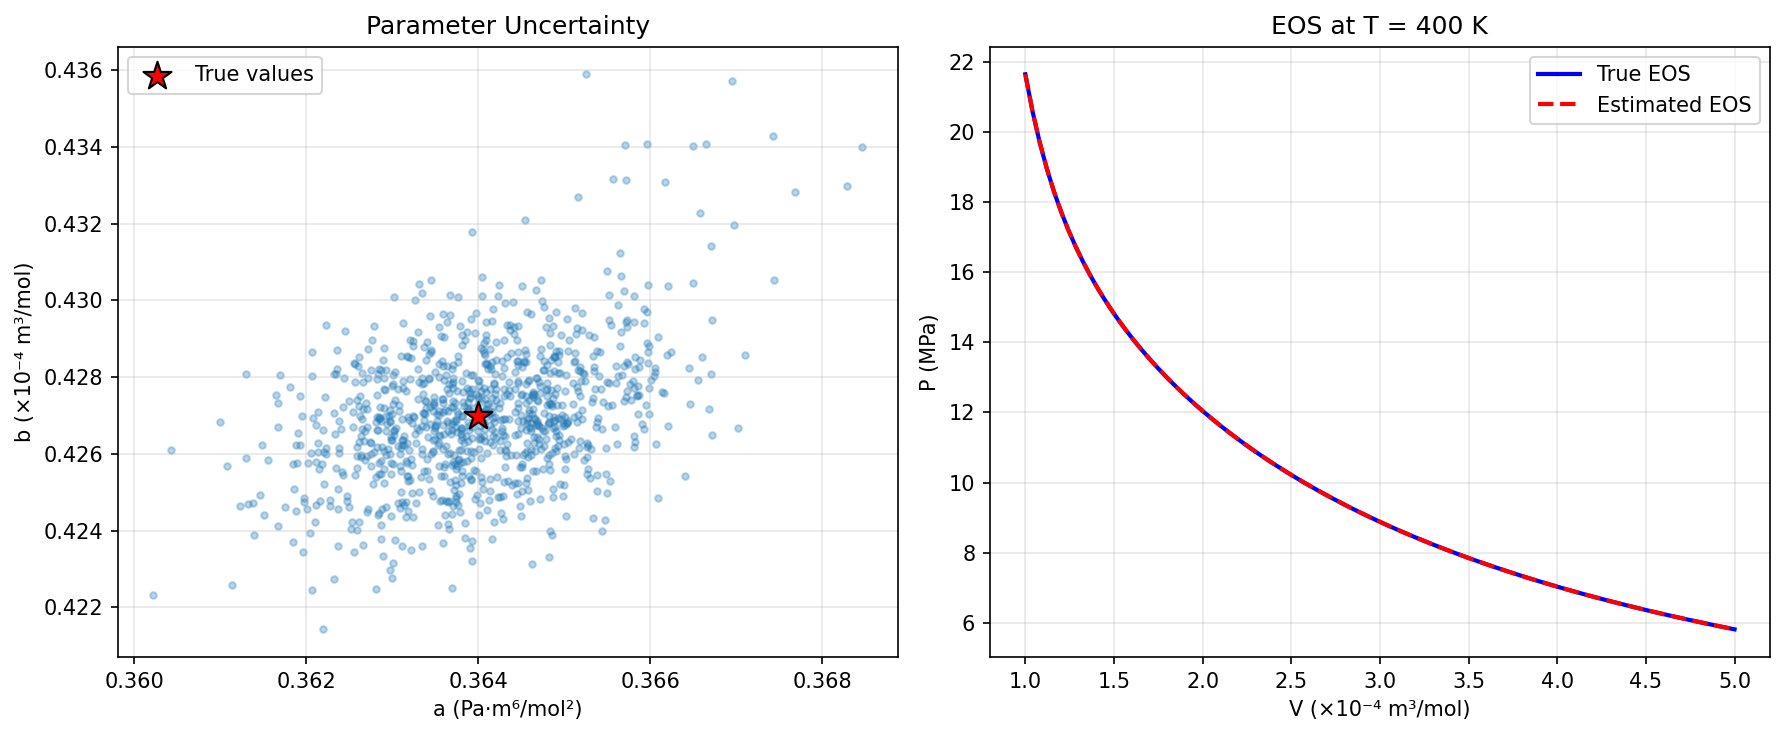

In [43]:
# Visualize parameter uncertainty
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Joint distribution
axes[0].scatter(a_est, b_est * 1e4, alpha=0.3, s=10)
axes[0].scatter([a_true], [b_true * 1e4], c='red', s=200, marker='*',
                edgecolors='black', label='True values', zorder=5)
axes[0].set_xlabel('a (Pa·m⁶/mol²)')
axes[0].set_ylabel('b (×10⁻⁴ m³/mol)')
axes[0].set_title('Parameter Uncertainty')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Verify fit
a_mean, b_mean = a_est.mean(), b_est.mean()
V_test = np.linspace(1e-4, 5e-4, 100)
T_test = 400  # K

P_true_curve = vdw_pressure(V_test, T_test, a_true, b_true) / 1e6
P_est_curve = vdw_pressure(V_test, T_test, a_mean, b_mean) / 1e6

axes[1].plot(V_test * 1e4, P_true_curve, 'b-', lw=2, label='True EOS')
axes[1].plot(V_test * 1e4, P_est_curve, 'r--', lw=2, label='Estimated EOS')
axes[1].set_xlabel('V (×10⁻⁴ m³/mol)')
axes[1].set_ylabel('P (MPa)')
axes[1].set_title(f'EOS at T = {T_test} K')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Summary

This notebook demonstrated generative approaches to 8 advanced optimization problems:

| Problem | Key Insight |
|---------|-------------|
| Multi-modal (Rastrigin) | Find all stationary points by conditioning on gradient=0 |
| Pareto front | Generate solutions for any trade-off by conditioning on objectives |
| Inverse design | Given target properties, sample feasible designs |
| PDE-constrained | Use dimensionality reduction (PCA) for high-dim fields |
| Trajectory optimization | Generate control sequences for desired final states |
| Robust optimization | Condition on low worst-case cost |
| Facility location | Condition on low total cost |
| EOS fitting | Parameter estimation from observations |

**Common pattern**: Build joint distribution, condition on desired outputs, sample inputs.